In [10]:
# Import standard libraries

# Third-Party Libraries
import numpy as np

# Import the Swarm Systems Lab Simulator
from ssl_simulator import add_src_to_path, set_log_format, set_log_level
from ssl_simulator.math import (
    construct_attitude_basis,
    so3_hat,
    so3_rotate_with_step,
)
from ssl_simulator.visualization import SO3Plot, set_paper_parameters

set_paper_parameters(fontsize=12)
set_log_level("DEBUG")
set_log_format("compact")

# # -------------------------------------------------------------------------------------
# # Import custom functions and classes (src in path is requiered)
# add_src_to_path("", deep=0)

SEED = 2025

[DEBUG] Shape changed: (3,) -> (1, 3)
[DEBUG] Shape changed: (3,) -> (1, 3)
[DEBUG] Shape changed: (50, 3, 3) -> (50, 1, 3, 3)
[DEBUG] Created axis 'attitude' with rect=[0, 0, 1, 1] and kwargs={'projection': '3d'}


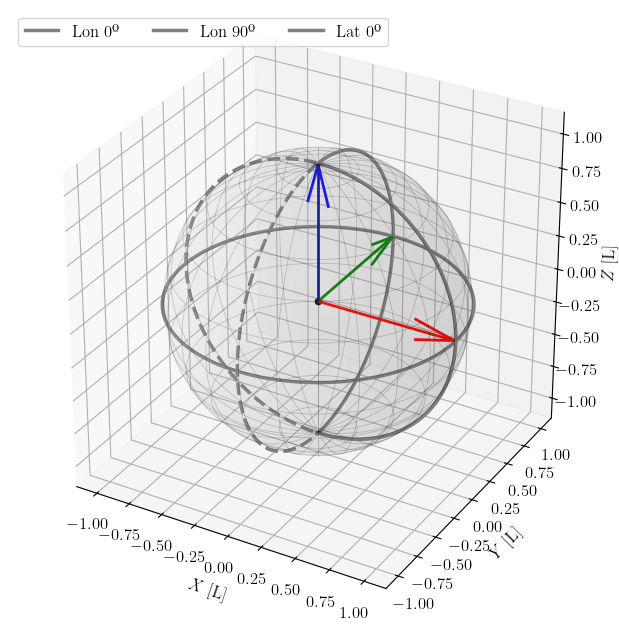

In [11]:
md = np.array([1, 0, 0])
gd = np.array([0, 0, -1])

# Generate a sequence of rotation matrices rotating around the z-axis
omega = np.linspace(0, 2 * np.pi, 50)[:, None] * np.array([0, -1, 0])
R0 = construct_attitude_basis(md, gd)
R = so3_rotate_with_step(R0, so3_hat(omega))

# Plotting the 3D heading trajectory
plot = SO3Plot(R, figsize=(6, 7), dpi=100)
plot.show()

In [12]:
plot.debug_artists()

[DEBUG] ----- PlotBase Artists Debug -----
[DEBUG] Axis 'attitude' (Axes3D):
[DEBUG]     [quivers] np.ndarray shape=(1, 1, 3), dtype=Line3DCollection
[DEBUG]     [scatter] np.ndarray shape=(1, 1), dtype=Path3DCollection
[DEBUG]     [sphere_wireframe] Line3DCollection: <mpl_toolkits.mplot3d.art3d.Line3DCollection object at 0x72fb99e5ad50>
[DEBUG]     [sphere_surface] Poly3DCollection: <mpl_toolkits.mplot3d.art3d.Poly3DCollection object at 0x72fb99e5ae90>
[DEBUG]     [meridian_lon0] Line3D: Line2D(Lon 0º)
[DEBUG]     [meridian_lon90] Line3D: Line2D(Lon 90º)
[DEBUG]     [meridian_lon0_dashed] Line3D: Line2D(_child8)
[DEBUG]     [meridian_lon90_dashed] Line3D: Line2D(_child9)
[DEBUG]     [equator] Line3D: Line2D(Lat 0º)
[DEBUG] Total artists: 11
[DEBUG] ---------------------------------


In [ ]:
plot.to_html()
# plot.save_mp4(OUTPUT_DIR)